# Course project: Classifying videos using machine learning

To develop a model to predict whether a TikTok video presents a 'claim' or an 'opinion'.
- A claim requires further human intervention, while an opinion does not.
- A claim that is misclassified as an opinion is undesirable.

Therefore, the aim would be identifying a 'claim' video as a 'positive' outcome.

**Target variable**

- 'claim_status': identifies which are 'claim' videos for further human intervention.

**Evaluation**
- Minimal false negatives i.e. misclassifying a claim as opinion
- Important model evaluation metric, recall = TP / (TP+FN)


### My work vs. course exemplar:
- *video_transcription_text*: Tokenization using *CountVectorizer()* is not covered here but it is shown in the course exemplar. The exemplar therefore has many more features for modeling.
- *train_test_split*: Though the class is quite balanced, *stratify* is used here, but not in exemplar. Observed that stratifying did improve the recall & precision scores slightly.
- *GridSearchCV*: Specify data for cv using *custom_split* here but exemplar uses *cv=5*.
- Exemplar obtains better recall score.

In [ ]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score,\
precision_score, recall_score, f1_score, classification_report

# Import packages for data modeling
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

EDA not shown here:  
- data.head(10)
- data.shape
- data.info()
- data.describe()
- data.isnull().sum()

No handling of outliers since tree-based models can handle outliers well.

In [ ]:
# Very few observations with missing values (298 out of 19382) -> so can be dropped
data = data.dropna(axis=0)
# Check for duplicates
data.duplicated().sum()

0

In [ ]:
# Check class balance
data['claim_status'].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

### Feature engineering

In [ ]:
# Add column: char length of video_transcription_text
data['text_len'] = data['video_transcription_text'].str.len()

# Get average text_len for claims and opinions
data[['claim_status', 'text_len']].groupby('claim_status').mean()

,text_len
claim_status,
claim,95.376978
opinion,82.722562


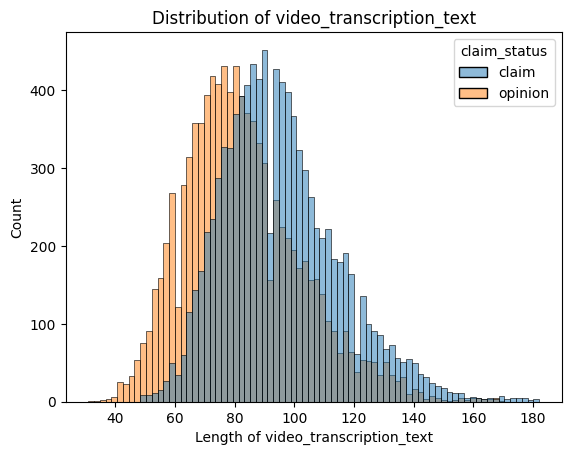

In [ ]:
# Visualize distribution of text_len for claims and opinions
sns.histplot(data, x='text_len', hue='claim_status', legend=True)
plt.xlabel('Length of video_transcription_text')
plt.ylabel('Count')
plt.title('Distribution of video_transcription_text')
plt.show()

In [ ]:
# Drop unnecessary columns
X = data.drop(['#', 'video_id', 'video_transcription_text'], axis=1)

# Encode target variable, identifying 'claim' videos
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})

# Dummy encode remaining categorical values
#X = pd.get_dummies(X, drop_first=True)
X = pd.get_dummies(X, columns=['verified_status', 'author_ban_status'],
                   drop_first=True)

X.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_len,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


### Split data

In [ ]:
# Isolate target variable
y = X['claim_status']

# Isolate features
X = X.drop(['claim_status'], axis=1)

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_len,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [ ]:
# Split data into training/validation/testing 60/20/20 sets
# 'stratify' even though class is quite balanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=0)

# Check shape of each set for alignment
print('training: ', X_tr.shape, y_tr.shape)
print('validation: ', X_val.shape, y_val.shape)
print('testing: ', X_test.shape, y_test.shape)

training:  (11450, 10) (11450,)
validation:  (3817, 10) (3817,)
testing:  (3817, 10) (3817,)


### Random forest model

In [ ]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators': [30, 50],
             'max_depth': [5],
             'max_features': [0.5],
             #'max_samples': [0.7],
             'min_samples_leaf': [1],
             'min_samples_split': [2]
            }

cv_params1 = {'n_estimators': [200, 300],
             'max_depth': [5,None],
             'max_features': [0.3, 'sqrt'],
             'min_samples_leaf': [1],
             'min_samples_split': [2]
            }

# Specify data for validation instead of using cv=5
split_index = [0 if i in X_val.index else -1 for i in X_train.index]
custom_split = PredefinedSplit(split_index)

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=custom_split, refit='recall')

In [ ]:
# Fit model to training data
%time
rf_cv.fit(X_train, y_train)    # for cv=custom_split
#rf_cv.fit(X_tr, y_tr)         # for cv=5

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 10.5 µs


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1, -1])),
             estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5], 'max_features': [0.5],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [30, 50]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
# Examine best recall score & best parameters
print('recall: ', rf_cv.best_score_)
rf_cv.best_params_

recall:  0.991675338189386


{'max_depth': 5,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 30}

In [ ]:
# Check precision score to make sure the model is not labeling everything as claims.
# Access the GridSearch results and convert it to a pandas df
rf_cv_results = pd.DataFrame(rf_cv.cv_results_)

# Examine GridSearch results df at column `mean_test_precision` in the best index
rf_cv_results['mean_test_precision'][rf_cv.best_index_]

1.0

### XGBoost model

In [ ]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5,8],
             #'max_depth': [3, 4],
             'min_child_weight': [3, 4],
             #'learning_rate': [0.05, 0.1],
             'learning_rate': [0.01, 0.05],
             #'n_estimators': [50, 100]
             'n_estimators': [150, 200]
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
#xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=custom_split, refit='recall')

In [ ]:
# Fit model to training data
%time
xgb_cv.fit(X_train, y_train)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 9.3 µs


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1, -1])),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.01, 0.05], 'max_depth': [5, 8],
                         'min_child_weight': [3, 4],
                         'n_estimators': [150, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
# Examine best recall score & best parameters
print('recall: ', xgb_cv.best_score_)
xgb_cv.best_params_

recall:  0.991675338189386


{'learning_rate': 0.01,
 'max_depth': 5,
 'min_child_weight': 4,
 'n_estimators': 150}

In [ ]:
# Assess GridSearch results to check precision score
xgb_cv_results = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_cv_results['mean_test_precision'][xgb_cv.best_index_]

0.9989517819706499

***rf_cv*** performs slightly better than ***xgb_cv***

### Evaluate random forest model

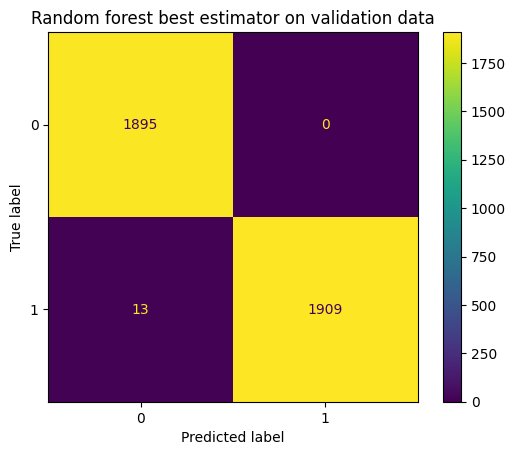

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1895
           1       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [ ]:
# Use random forest "best estimator" model to get predictions on validation set
y_pred_rf = rf_cv.best_estimator_.predict(X_val)

# Create confusion matrix to visualize results
# Compute values for confusion matrix
cm_rf = confusion_matrix(y_val, y_pred_rf)

# Create display of confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_cv.classes_)
disp_rf.plot()
plt.title('Random forest best estimator on validation data');
plt.show()

# Create classification report
print(classification_report(y_val, y_pred_rf))

### Evaluate XGBoost model

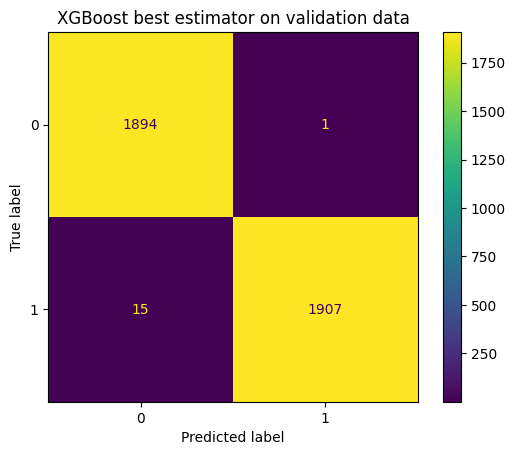

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1895
           1       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [ ]:
# Use XGB "best estimator" model to get predictions on validation set
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val)

# Create confusion matrix to visualize results
# Compute values for confusion matrix
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

# Create display of confusion matrix
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_cv.classes_)
disp_xgb.plot()
plt.title('XGBoost best estimator on validation data');
plt.show()

# Create classification report
print(classification_report(y_val, y_pred_xgb))

- Both models offer almost the same performance, with ***rf_cv*** performs slightly better than ***xgb_cv***.
- To explore more features to potentially lower false negatives further.

### Use champion model to predict on test data

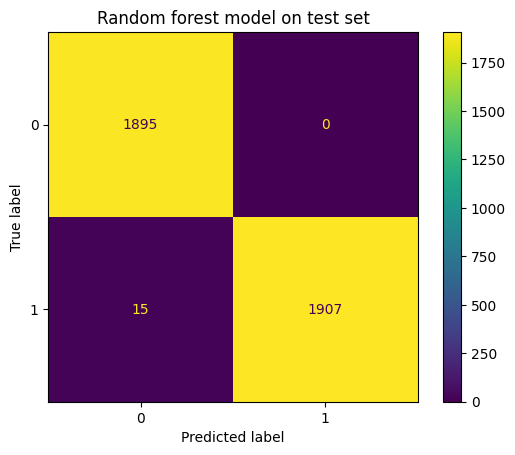

In [ ]:
# Use champion model to predict on test data
y_pred = rf_cv.best_estimator_.predict(X_test)

# Compute values for confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create display of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=None)

# Plot confusion matrix
disp.plot()
# Display plot
plt.title('Random forest model on test set');
plt.show()


### Feature importances of champion model

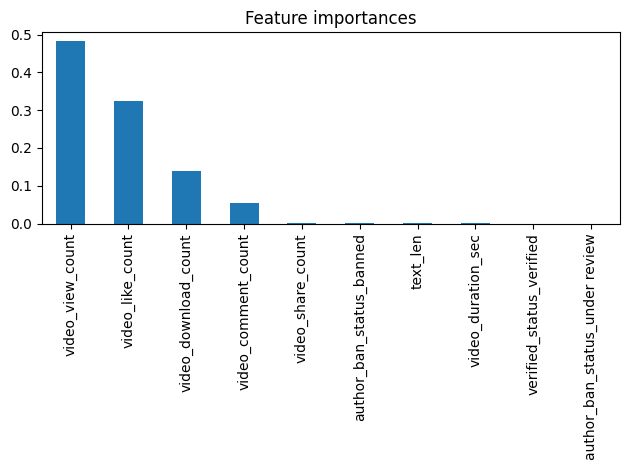

In [ ]:
#plot_importance(xgb_opt)

importances = rf_cv.best_estimator_.feature_importances_

rf_impt = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
rf_impt.plot.bar(ax=ax)
ax.set_title('Feature importances')
fig.tight_layout()


This plot shows the most predictive features (in descending order) which are very much related to video engagement levels.